In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv(r"C:\Users\rohit\Downloads\Retail_Sales_400_Records.csv")

In [4]:
if df.isnull().sum().sum() > 0:
    df = df.dropna() 

In [5]:
X = df[['Sales', 'Quantity', 'Discount']]
y = df['Profit']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
regmodel = LinearRegression()
regmodel.fit(X_train_scaled, y_train)

LinearRegression()

In [9]:
pickle.dump(regmodel, open('regmodel.pkl', 'wb'))
pickle.dump(scaler, open('scaling.pkl', 'wb'))

In [10]:
print("Models created and saved successfully!")

Models created and saved successfully!


In [11]:
model = pickle.load(open('regmodel.pkl', 'rb'))
scalar = pickle.load(open('scaling.pkl', 'rb'))

In [13]:
test_data = np.array([5000, 10, 0.15]).reshape(1, -1)
scaled_data = scalar.transform(test_data)
prediction = model.predict(scaled_data)
print(f"Predicted Profit: {prediction}")

Predicted Profit: [622.40102804]


C:\Users\rohit\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

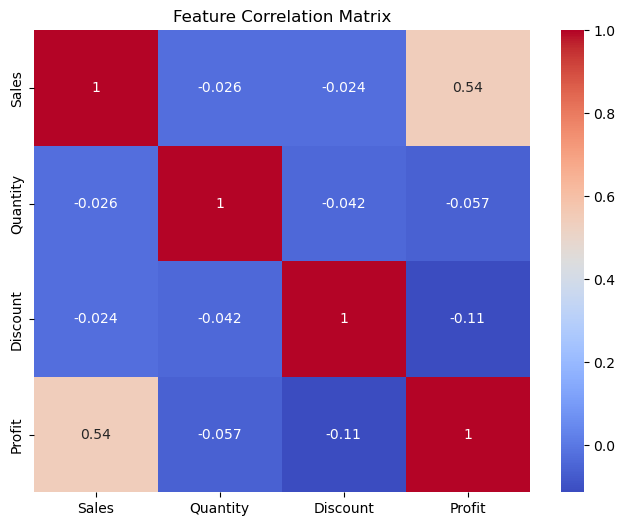

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales', 'Quantity', 'Discount', 'Profit']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

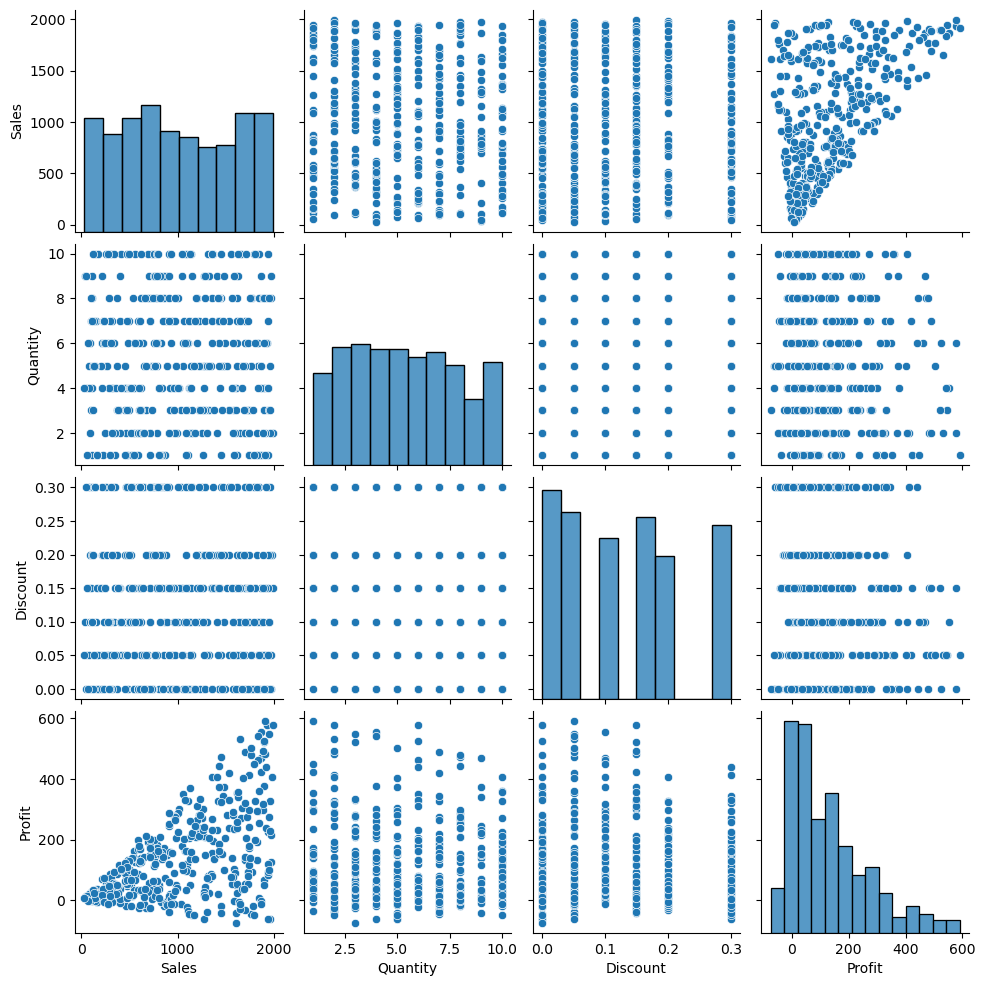

In [16]:
sns.pairplot(df[['Sales', 'Quantity', 'Discount', 'Profit']])
plt.show()

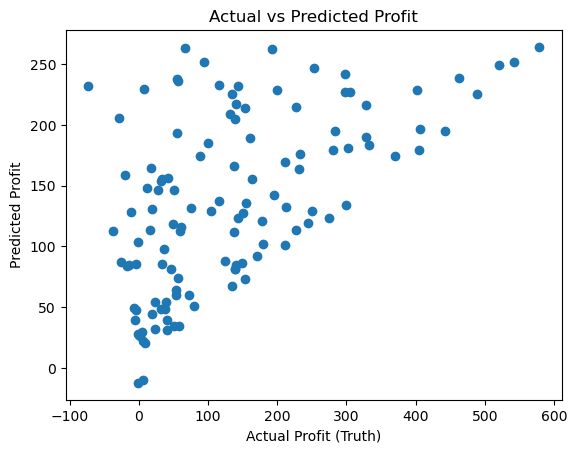

In [20]:
reg_pred = regmodel.predict(X_test_scaled) 
plt.scatter(y_test, reg_pred)
plt.xlabel("Actual Profit (Truth)")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.show()